In [2]:
import pandas as pd 
import numpy as npn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import joblib

In [3]:
# Load data
df = pd.read_csv('European_Bank.csv')

In [4]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [6]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [11]:
df.columns.tolist()

['Year',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [15]:
# No need to drop anything (dataset already clean)
df.columns = df.columns.str.strip()

In [18]:
# Feature Engineering

In [16]:
# Engagemnet Score
df['EngagementScore'] = df['IsActiveMember']*df['NumOfProducts']

In [17]:
#fincancial Behavior
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] +1)

In [19]:
# lifestyle
df['TenureRatio'] = df['Tenure'] / (df['Age'] +1)

In [21]:
#product usage by category
df['ProductUsageLevel'] = pd.cut(df['NumOfProducts'],  bins=[0,1,2,4],
    labels=['Low','Medium','High'])

In [22]:
# high value customers
threshold = df['Balance'].quantile(0.75)
df['IsHighValueCustomer'] = (df['Balance']>threshold).astype(int)

In [23]:
# High-value but inactive
df['IsDisengagedHighValue'] = (
    (df['IsHighValueCustomer'] == 1) &
    (df['IsActiveMember'] == 0)
).astype(int)

In [24]:
df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,EngagementScore,BalanceSalaryRatio,TenureRatio,ProductUsageLevel,IsHighValueCustomer,IsDisengagedHighValue
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,0.000000,0.046512,Low,0,0
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,0.744670,0.023810,Low,0,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,1.401362,0.186047,High,1,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,0.000000,0.025000,Medium,0,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1,1.587035,0.045455,Low,0,0


In [25]:
## EDA 

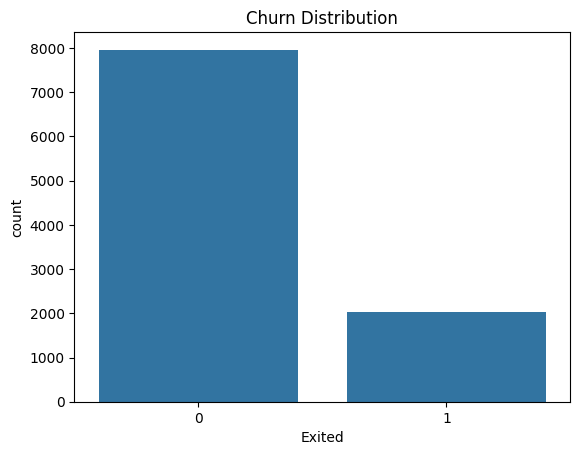

In [26]:
#churn Distribution 

sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

- Insight:
- Dataset is imbalanced → churn ~20-30%

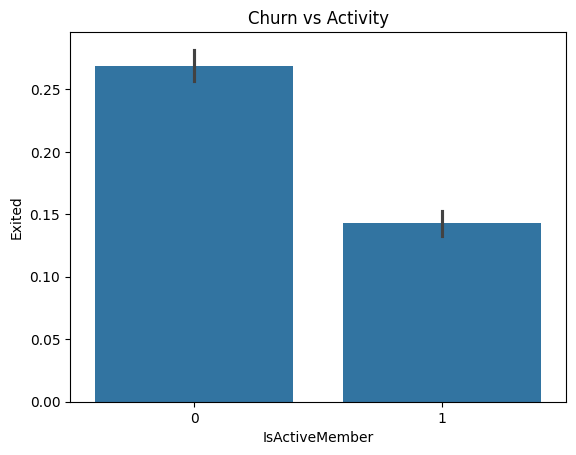

In [28]:
# Engagement vs Churn 

sns.barplot(x='IsActiveMember', y='Exited', data=df)
plt.title("Churn vs Activity")
plt.show()

- Insight:
- Inactive customers churn significantly more → strongest feature

In [29]:
df.columns

Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'EngagementScore', 'BalanceSalaryRatio',
       'TenureRatio', 'ProductUsageLevel', 'IsHighValueCustomer',
       'IsDisengagedHighValue'],
      dtype='str')

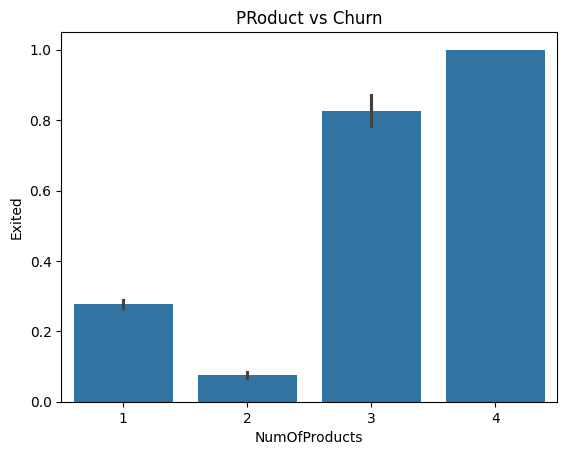

In [30]:
# Product vs Churn 

sns.barplot(x='NumOfProducts', y='Exited',data=df)
plt.title("PRoduct vs Churn")
plt.show()

- Insight:
- Customers with 2 products show lowest churn → optimal engagement

In [32]:
#. TRAIN-TEST SPLIT 

In [33]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
# ML Pipeline

In [34]:
num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include=['object','category']).columns

C:\Users\sahil\AppData\Local\Temp\ipykernel_2140\4205000937.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object','category']).columns


In [35]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])


In [36]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [38]:
#HYPERPARAMETER TUNING 

In [39]:
param_gird = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None]
}

In [40]:
grid = GridSearchCV(pipeline, param_gird, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [41]:
model = grid.best_estimator_

In [42]:
print("Best Params:", grid.best_params_)

Best Params: {'model__max_depth': 10, 'model__n_estimators': 200}


In [43]:
# model Evalution 

In [44]:
preds = model.predict(X_test)

In [45]:
probs = model.predict_proba(X_test)[:, 1]

In [47]:
print(classification_report(y_test, preds))
print("ROC_AUC:", roc_auc_score(y_test, probs))
print("Confusion Metrix:\n", confusion_matrix, preds)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.45      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

ROC_AUC: 0.865253954154138
Confusion Metrix:
 <function confusion_matrix at 0x000002AA1B08A820> [0 0 0 ... 1 0 0]


### Interpretation:
- ROC-AUC > 0.8 → strong model
- Recall → ability to detect churners
- Precision → quality of predictions

In [48]:
# Feature Importtance

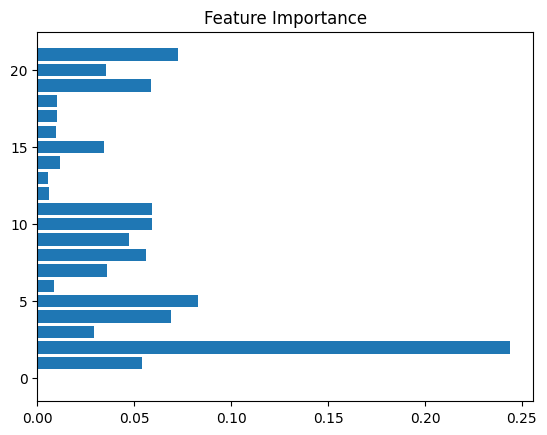

In [50]:
import matplotlib.pyplot as plt

importances = model.named_steps['model'].feature_importances_

plt.barh(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

In [52]:
# save model 
joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [53]:
df.columns

Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'EngagementScore', 'BalanceSalaryRatio',
       'TenureRatio', 'ProductUsageLevel', 'IsHighValueCustomer',
       'IsDisengagedHighValue'],
      dtype='str')

In [55]:
## KPI Calculations

def calculate_kpis(df):

    ERR = 1 - df[df['IsActiveMember'] ==1]['Exited'].mean()
    PDI = df['NumOfProducts'].mean()
    HBDR = df[df['IsHighValueCustomer']==1]['IsActiveMember'].value_counts(normalize=True).get(0,0)
    CCS = df[df['HasCrCard']==1]['Exited'].mean()
    RSI = df['EngagementScore'].mean()


    return {
        "Engagement Retention Ratio": ERR,
        "Product Depth Index": PDI,
        "High Balance Disengagement Rate": HBDR,
        "Credit Card Stickiness": CCS,
        "Relationship Strength Index": RSI
    }

calculate_kpis(df)

{'Engagement Retention Ratio': np.float64(0.8573092603377985),
 'Product Depth Index': np.float64(1.5302),
 'High Balance Disengagement Rate': np.float64(0.4988),
 'Credit Card Stickiness': np.float64(0.20184266477675408),
 'Relationship Strength Index': np.float64(0.791)}